# Yolo
https://docs.ultralytics.com/models/yolov8/#key-features-of-yolov8

https://platform.ultralytics.com/ultralytics/yolov8/yolov8n

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
# results = model("https://ultralytics.com/images/bus.jpg")
results = model("./test.jpg")


# Show result
results[0].show()

print("YOLO output example:")
print(results[0].boxes)


image 1/1 /home/lupasic/Programs/AIS/lectures/06/extra_materials/clearml_tests/scripts/test.jpg: 480x640 9 persons, 4 bottles, 3 wine glasss, 5 cups, 4 chairs, 2 dining tables, 55.1ms
Speed: 1.7ms preprocess, 55.1ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)
YOLO output example:
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 0.,  0.,  0.,  0.,  0.,  0., 39., 60.,  0.,  0., 56.,  0., 40., 41., 40., 56., 41., 56., 39., 41., 41., 60., 40., 56., 41., 39., 39.])
conf: tensor([0.9127, 0.8266, 0.8160, 0.8059, 0.7997, 0.7878, 0.7496, 0.6890, 0.6809, 0.6780, 0.6628, 0.6191, 0.5356, 0.4755, 0.4559, 0.4278, 0.3885, 0.3694, 0.3648, 0.3603, 0.3432, 0.3371, 0.3200, 0.2785, 0.2726, 0.2703, 0.2699])
data: tensor([[9.7231e+01, 3.7369e+02, 3.9782e+02, 9.5963e+02, 9.1269e-01, 0.0000e+00],
        [2.6976e+02, 3.6632e+02, 4.3946e+02, 5.7419e+02, 8.2665e-01, 0.0000e+00],
        [1.0550e+03, 3.7621e+02, 1.1567e+03, 5.8029e+02, 8.1601e-01, 0.0000e+00],
       

# Image classification (ResNet18)

Используем устройство: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/lupasic/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:02<00:00, 17.7MB/s]


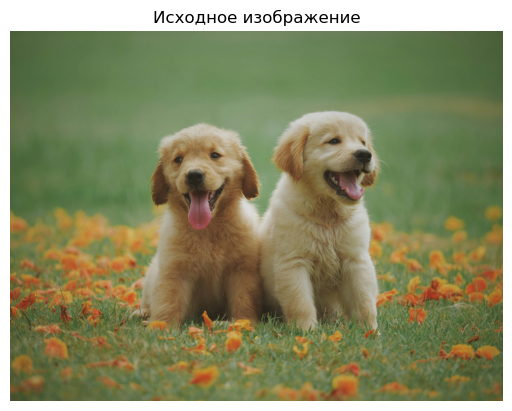


Top-5 предсказаний:
golden retriever: 0.861
clumber: 0.030
Labrador retriever: 0.029
cocker spaniel: 0.017
Sussex spaniel: 0.007


In [6]:
import torch
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import requests
from io import BytesIO
from matplotlib import pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Используем устройство:", device)

# -------------------------
# 2. Загрузка модели ResNet18
# -------------------------
# Новый API c weights (PyTorch 2.x)
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)
model = model.to(device)
model.eval()

# Трансформации такие же, как при обучении на ImageNet
preprocess = weights.transforms()

# -------------------------
# 3. Загрузка картинки (пример: собака)
# -------------------------
url = "https://images.pexels.com/photos/1108099/pexels-photo-1108099.jpeg"
response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.title("Исходное изображение")
plt.show()

# Преобразуем в тензор
input_tensor = preprocess(img).unsqueeze(0)  # [1, 3, 224, 224]
input_tensor = input_tensor.to(device)

# -------------------------
# 4. Прямой проход через сеть
# -------------------------
with torch.no_grad():
    outputs = model(input_tensor)
    probs = torch.softmax(outputs, dim=1)[0]

# -------------------------
# 5. Расшифровка top-5 классов
# -------------------------
# Классы ImageNet уже зашиты в weights.meta["categories"]
categories = weights.meta["categories"]

top5_prob, top5_catid = torch.topk(probs, 5)
print("\nTop-5 предсказаний:")
for p, c in zip(top5_prob, top5_catid):
    print(f"{categories[c]}: {p.item():.3f}")

# -------------------------
# 6. Функция для быстрого теста других картинок
# -------------------------
def predict_from_url(url: str, topk: int = 5):
    print("\n=== Новое изображение ===")
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    plt.imshow(img)
    plt.axis("off")
    plt.title("Новое изображение")
    plt.show()

    input_tensor = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
    top_prob, top_catid = torch.topk(probs, topk)

    print(f"Top-{topk} предсказаний:")
    for p, c in zip(top_prob, top_catid):
        print(f"{categories[c]}: {p.item():.3f}")

# Пример использования:
# predict_from_url("https://images.pexels.com/photos/145939/pexels-photo-145939.jpeg")  # кот


=== Новое изображение ===


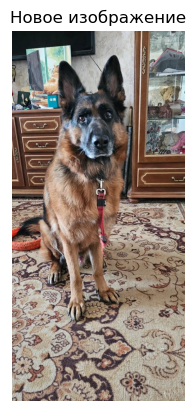

Top-5 предсказаний:
malinois: 0.565
German shepherd: 0.228
Leonberg: 0.152
kelpie: 0.009
Tibetan mastiff: 0.007


In [12]:
predict_from_url("https://downloader.disk.yandex.ru/preview/4e7ac2bd2fe4b0fd273cb4be0cf44313fe9eaf9b225412e28378bd141620d344/69bb1036/iSz3hMw_ON2aZYU0f_XvUkaIO67lIHq5r760CBnHhlF98oErwIw8Ys9cyorFFe293wxN_G4_nyjtoJEFZFBlMA%3D%3D?uid=0&filename=2026-03-17%2013-39-10.JPG&disposition=inline&hash=&limit=0&content_type=image%2Fjpeg&owner_uid=0&tknv=v3&size=2048x2048")

# Hugging Face
[## Huggingface_hub](https://huggingface.co/docs/transformers/main_classes/pipelines)

In [2]:
# =========================================
from transformers import pipeline

clf = pipeline(model="FacebookAI/roberta-large-mnli")
result = clf("I love this lecture!")

print("NLP result:", result)

KeyboardInterrupt: 

# Sklearn

In [14]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X, y = load_iris(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("LogReg predictions:", preds[:10])

# =========================================
# 5. Clustering (KMeans)
# =========================================
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

print("Cluster centers:", kmeans.cluster_centers_)

LogReg predictions: [2 1 0 0 2 0 2 0 1 1]
Cluster centers: [[      5.006       3.428       1.462       0.246]
 [     5.8836       2.741      4.3885      1.4344]
 [     6.8538      3.0769      5.7154      2.0538]]
